# Two-State Benchmark

Goal: validate the finite-state estimator on the smallest benchmark where the objective landscape, population flow, and learned action probabilities are easy to inspect.

**Environment Basics**

- State space: $\mathcal{X}=\{0,1\}$. State 1 receives the positive state reward.
- Action space: $\mathcal{A}=\{ST,MV\}$, encoded as `{0, 1}`. `ST` keeps the state fixed; `MV` attempts to switch $x$ to $1-x$ with state-dependent probability $\lambda_x$.
- Population law: $\mu_t=(\mu_t(0),\mu_t(1))$. The main plotted population coordinate is $\mu_t(1)$.
- Policy: a static Bernoulli-logit policy with one move logit per state, so $\pi_\theta(MV\mid x)=\sigma(\theta_x)$.
- Main task: keep enough mass in state 1 while staying close to the target law $B$.

The mean-field control objective is

$$
J(\theta)=\mathbb{E}_\theta\left[\sum_{t=0}^{T-1} r(X_t,A_t,\mu_t)+g(X_T,\mu_T)\right],
\qquad
\mu_{t+1}(y)=\sum_x \mu_t(x)\sum_a \pi_\theta(a\mid x,\mu_t)P(y\mid x,a,\mu_t).
$$

For this environment, the running reward used by the code is

$$
r(x,a,\mu)=\mathbf{1}_{\{x=1\}}-\mu(1)^2-\lambda_{env}\,|\mu(1)-B(1)|.
$$

The notebook regenerates or loads the saved bundle, checks figure coverage against `docs/figures.md`, and renders all figures from CSV/JSON artifacts.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from mfc.experiments import notebook_helpers as nh

ENV_NAME = "twostate"
BASE_DIR = ROOT / "runs" / "notebook_bundles" / ENV_NAME
PRESET = "smoke"
QUICK = PRESET == "smoke"
RUN_MISSING = True
FORCE_REBUILD = False
EXTENDED = True

In [2]:
bundle = (
    nh.ensure_discrete_benchmark_bundle(ENV_NAME, BASE_DIR, quick=QUICK, force=FORCE_REBUILD, extended=EXTENDED, preset=PRESET)
    if RUN_MISSING
    else nh.bundle_paths(ENV_NAME, BASE_DIR)
)
bundle

{'env': 'twostate',
 'base_dir': PosixPath('/home/adonis/Internship/MFC_RL/runs/notebook_bundles/twostate'),
 'train': {'simplex': PosixPath('/home/adonis/Internship/MFC_RL/runs/notebook_bundles/twostate/train/twostate_simplex'),
  'logits': PosixPath('/home/adonis/Internship/MFC_RL/runs/notebook_bundles/twostate/train/twostate_logits')},
 'application': {'simplex': PosixPath('/home/adonis/Internship/MFC_RL/runs/notebook_bundles/twostate/application/twostate_simplex'),
  'logits': PosixPath('/home/adonis/Internship/MFC_RL/runs/notebook_bundles/twostate/application/twostate_logits')},
 'diagnostics': {'simplex': {'perturbation': PosixPath('/home/adonis/Internship/MFC_RL/runs/notebook_bundles/twostate/diagnostics/twostate_simplex_perturbation'),
   'functional_law': PosixPath('/home/adonis/Internship/MFC_RL/runs/notebook_bundles/twostate/diagnostics/twostate_simplex_functional_law'),
   'gradient': PosixPath('/home/adonis/Internship/MFC_RL/runs/notebook_bundles/twostate/diagnostics/twost

## Figure Coverage

Goal: show which requested results from `docs/figures.md` are currently produced by this notebook and which artifacts support them.

The tables are an audit layer, not an estimator. A row maps a desired result family to the command or study that generates its data and to the notebook helper that renders it.

In [3]:
nh.figure_checklist(ENV_NAME)

,figure_family,command_or_study,files,notebook_section
0,perturbation_geometry,diagnose-perturbation,"diagnostics.csv, perturbation_samples.csv",universal diagnostics
1,functional_law,diagnose-functional-law,"diagnostics.csv, signature_samples.csv, functi...",universal diagnostics
2,score_validation,score-validation,"diagnostics.csv, score_coordinates.csv, score_...",universal diagnostics
3,gradient_validation,diagnose-gradient,"diagnostics.csv, gradient_samples.csv, gradien...",universal diagnostics
4,sensitivity_validation,diagnose-sensitivity,"diagnostics.csv, sensitivity_samples.csv",universal diagnostics
5,horizon_scaling,horizon-scaling,"grid_metrics.csv, diagnostics.csv",study sweeps
6,budget_allocation,budget-allocation,"grid_metrics.csv, diagnostics.csv",study sweeps
7,particle_approximation,particle-approximation,"grid_metrics.csv, diagnostics.csv",study sweeps
8,particle_transfer,particle-transfer,"diagnostics.csv, optimization_history.csv",study sweeps
9,ablation,ablation,"grid_metrics.csv, diagnostics.csv",study sweeps


In [4]:
nh.figure_coverage_matrix(ENV_NAME)

,figure_or_result,status,notebook_helper,artifact
0,"perturbation mean, bands, and empirical slopes",ready,"plot_perturbation_geometry, plot_perturbation_...",diagnostics/*_perturbation/diagnostics.csv
1,finite-state d_TV perturbation calibration and...,ready,"perturbation_tv_comparison_table, plot_perturb...","diagnostics/*_perturbation/diagnostics.csv, di..."
2,functional-law signature summaries,ready,"plot_functional_law, plot_functional_signature...",diagnostics/*_functional_law/diagnostics.csv
3,"functional-law histograms, pair plots, Q-Q plots",ready,plot_functional_sample_diagnostics,diagnostics/*_functional_law/signature_samples...
4,"score mean, variance, lambda^2 variance, coord...",ready,"plot_score_validation, plot_score_coordinate_d...",diagnostics/*_score/*.csv
5,"gradient bias, variance, MSE, cosine, norm, de...",ready,"plot_gradient_validation, plot_gradient_error_...",diagnostics/*_gradient/diagnostics.csv
6,coordinatewise gradient scatter and CI coverage,ready,plot_gradient_coordinate_diagnostics,diagnostics/*_gradient/gradient_coordinates.cs...
7,sensitivity error vs time/eta and heatmap,ready,"plot_sensitivity_validation, plot_sensitivity_...",diagnostics/*_sensitivity/diagnostics.csv
8,budget allocation heatmap and runtime Pareto,ready,"plot_budget_and_horizon, plot_budget_pareto",studies/budget_allocation/*.csv
9,horizon scaling,ready,plot_budget_and_horizon,studies/horizon_scaling/*.csv


## Training: Simplex vs Logits

Goal: compare the optimization traces of the two finite-state perturbation geometries.

The value/objective plot estimates $J(\theta_k)$ at training episode $k$. The gradient plot tracks $\|\widehat g_k\|_2$, where $\widehat g_k$ is the MF-REINFORCE gradient estimate used by Adam.

Simplex uses affine law perturbations on the simplex; logits uses logistic-normal perturbations in logit coordinates. The curves should be compared using the same saved train/evaluation budget.

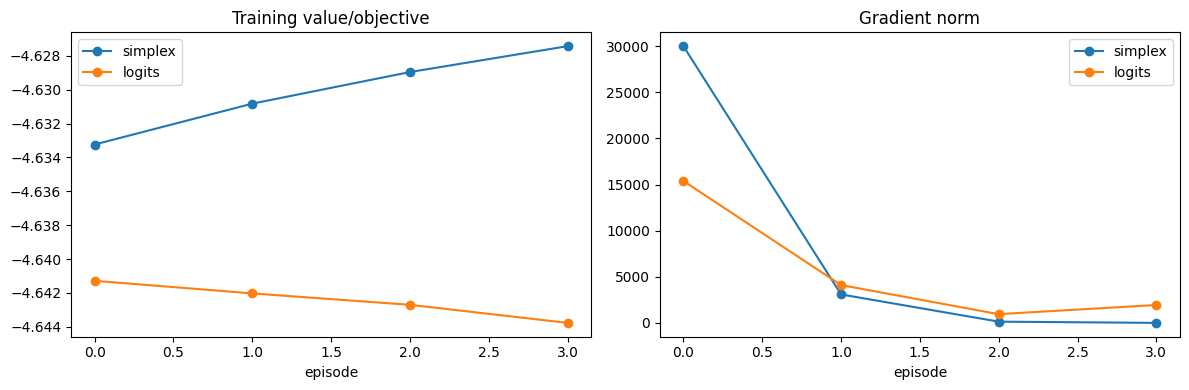

In [5]:
histories = nh.load_training_histories(bundle)
nh.plot_training_comparison(histories)

## Application Diagnostics

Goal: connect the learned policy to the actual two-state population behavior.

Reference: the table, dashed trajectory, and reference policy heatmap use the analytic optimal stationary policy $\pi^*$ for the two-state benchmark.

The population-flow plots show $\mu_t(0)$ and $\mu_t(1)$. The benchmark-specific panel compares $\mu_t(1)$ with the target $B(1)$, plots learned action probabilities $\pi_\theta(a\mid x,\mu_t)$ by state, and shows the exact objective landscape slice $J(\theta_0,\theta_1)$.

/home/adonis/Internship/MFC_RL/src/mfc/experiments/notebook_helpers.py:949: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(fontsize="small")


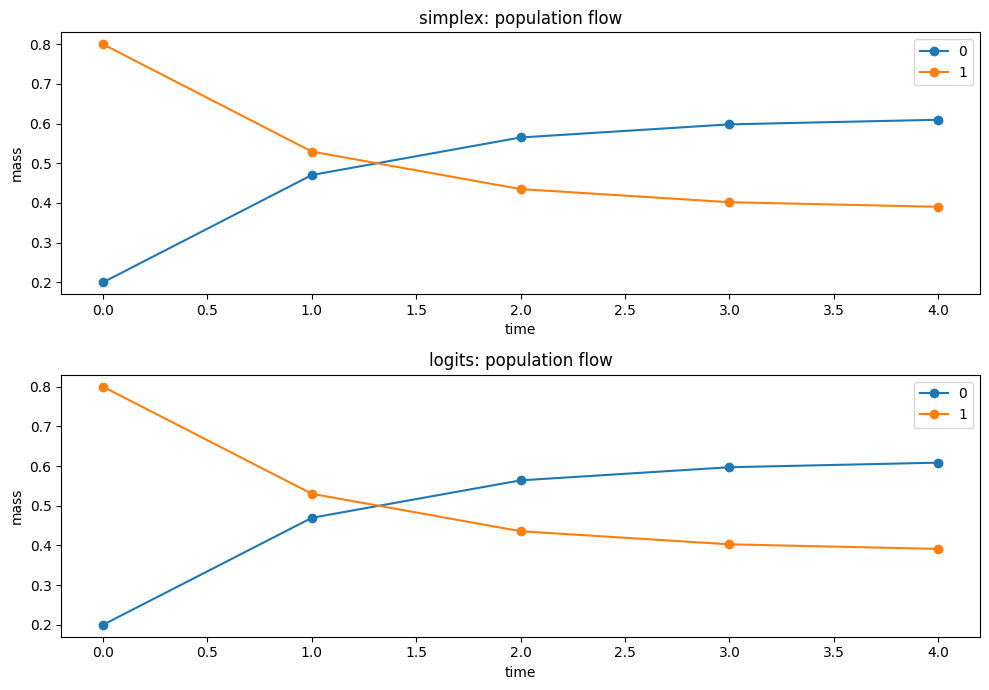

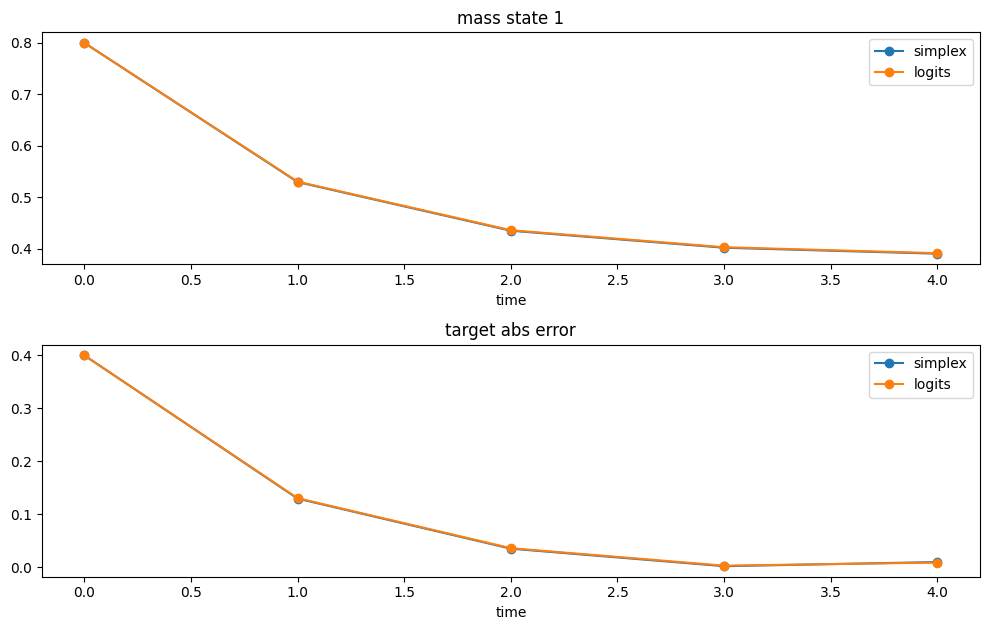

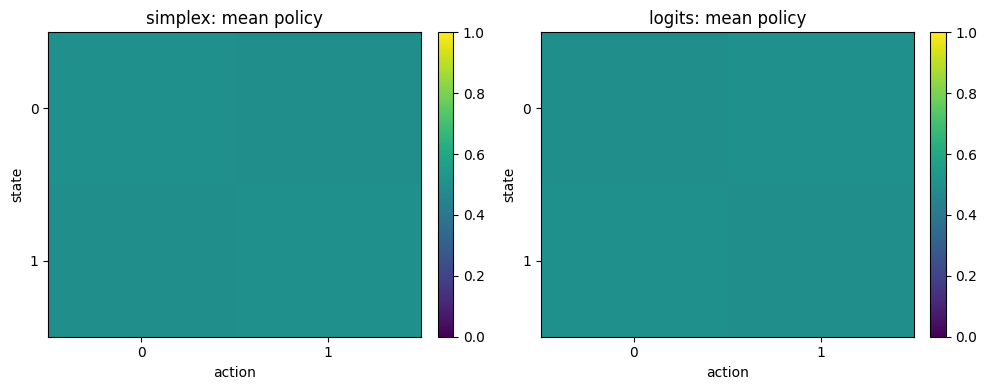

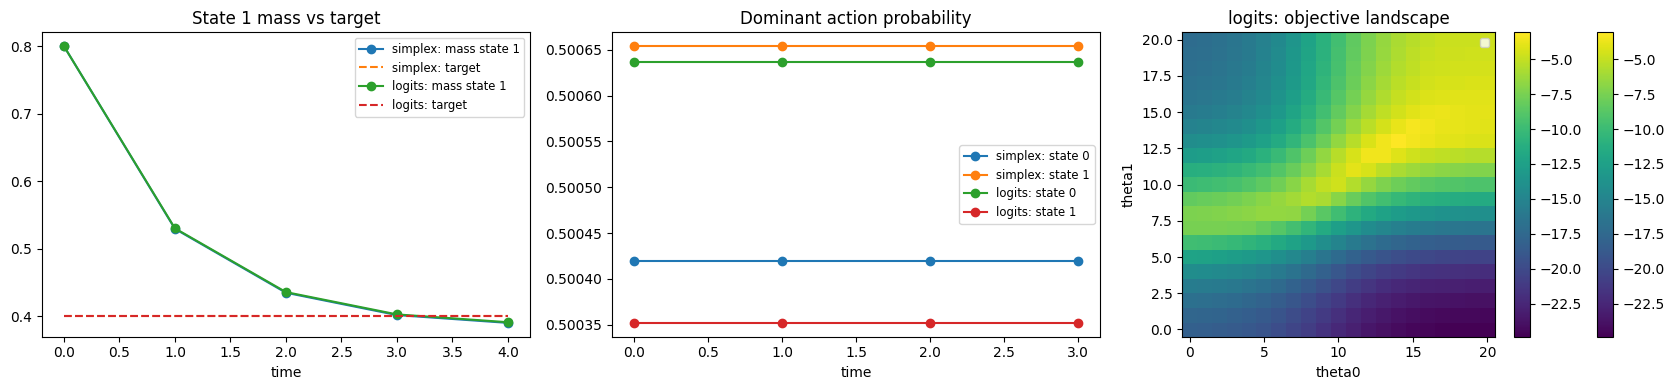

In [6]:
application = nh.load_application_data(bundle)
display(nh.reference_solution_table(ENV_NAME, application))
nh.plot_population_flow(application, ENV_NAME)
nh.plot_time_metrics(application, ENV_NAME)
nh.plot_policy_heatmaps(application, ENV_NAME)
nh.plot_discrete_application_details(application, ENV_NAME)

## Universal Diagnostics

Goal: validate the estimator chain before interpreting optimization performance.

The perturbation plots measure empirical geometry,

$$
d(M^\lambda,\mu),
$$

including quantile bands and local log-log slopes. The functional-law plots study

$$
\Gamma(M^\lambda)=(F_1(M^\lambda),\ldots,F_k(M^\lambda)),
\qquad
\frac{\Gamma(M^\lambda)-\Gamma(\mu)}{\lambda},
$$

which is the induced law of population signatures. The score plots check

$$
S_{t,\lambda}^\theta=\nabla_\theta\log q_{t,\lambda}^\theta(M_t),
\qquad \mathbb{E}[S_{t,\lambda}^\theta]\approx 0,
$$

and the gradient plots report bias, variance, MSE, norm ratio, and cosine agreement for an estimator $\widehat g$ against an oracle or reference gradient $g$:

$$
\operatorname{MSE}=\mathbb{E}\|\widehat g-g\|_2^2,
\qquad
\cos(\widehat g,g)=\frac{\widehat g\cdot g}{\|\widehat g\|_2\|g\|_2}.
$$

The sensitivity plots track errors in $D_t=\partial_\theta\Gamma(\mu_t^\theta)$, or in the finite-state case $D_t=\partial_\theta\mu_t^\theta$.

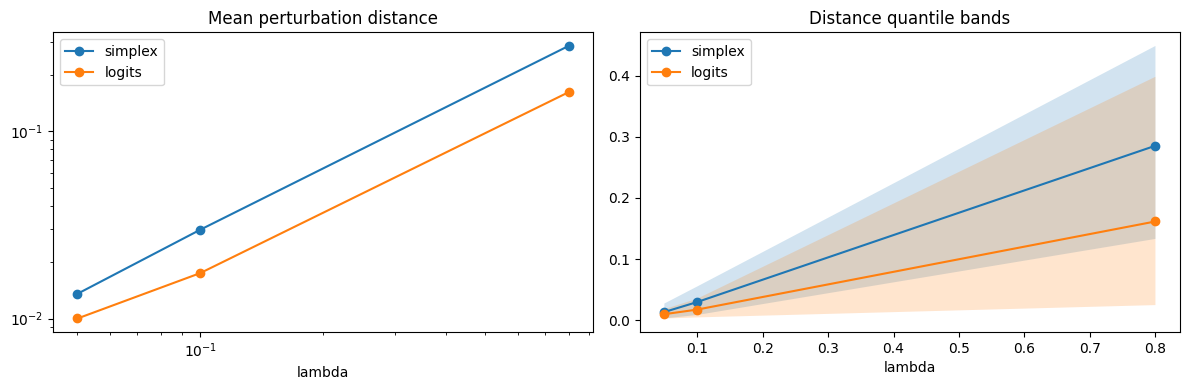

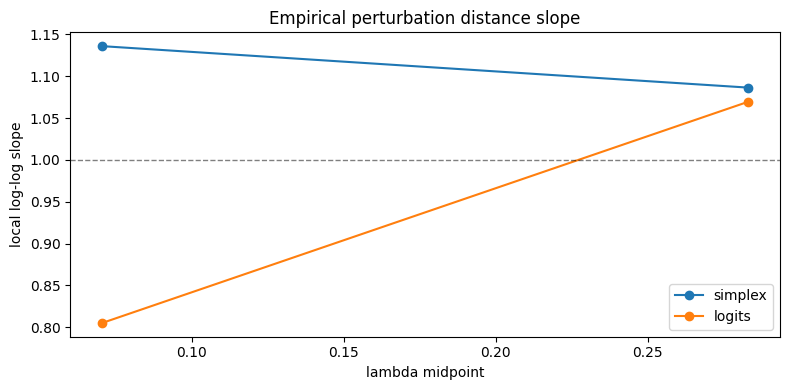

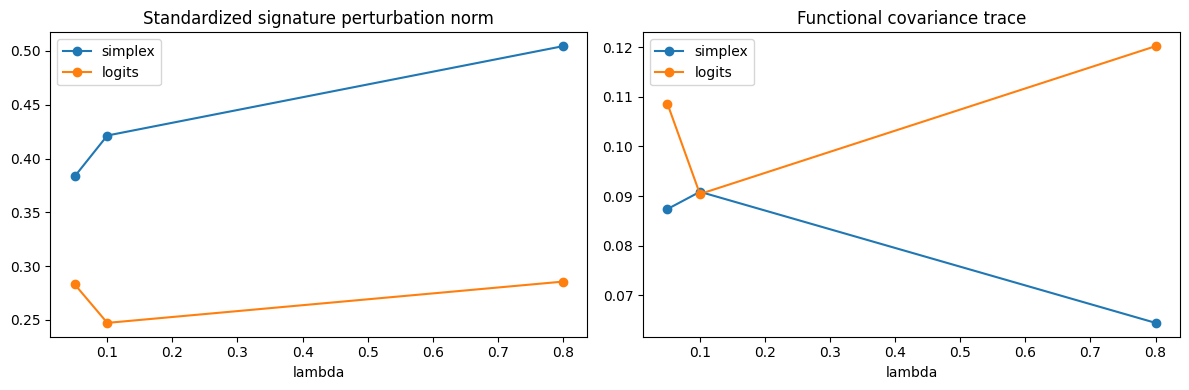

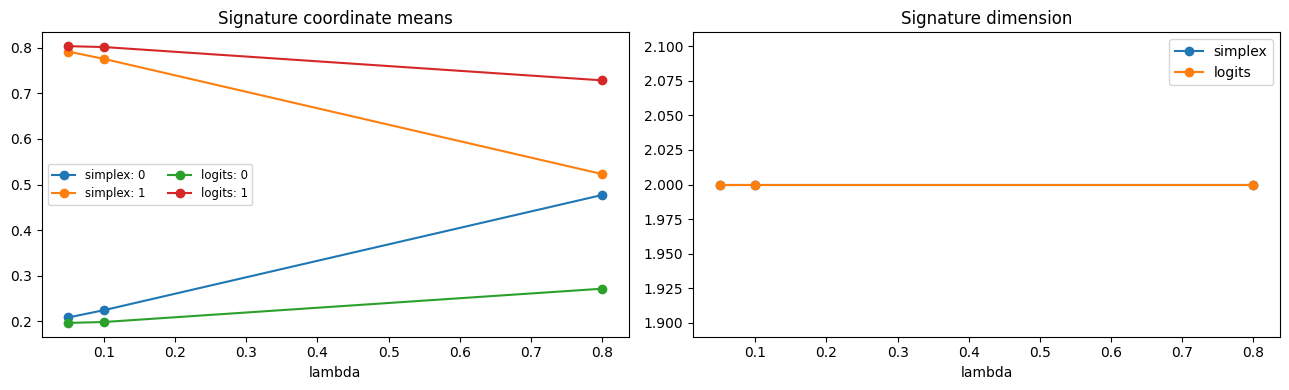

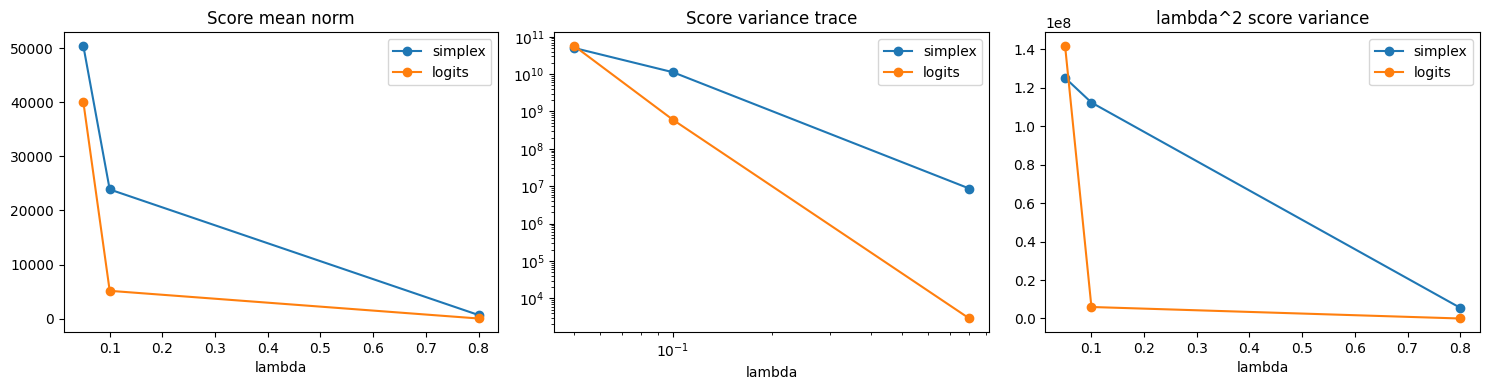

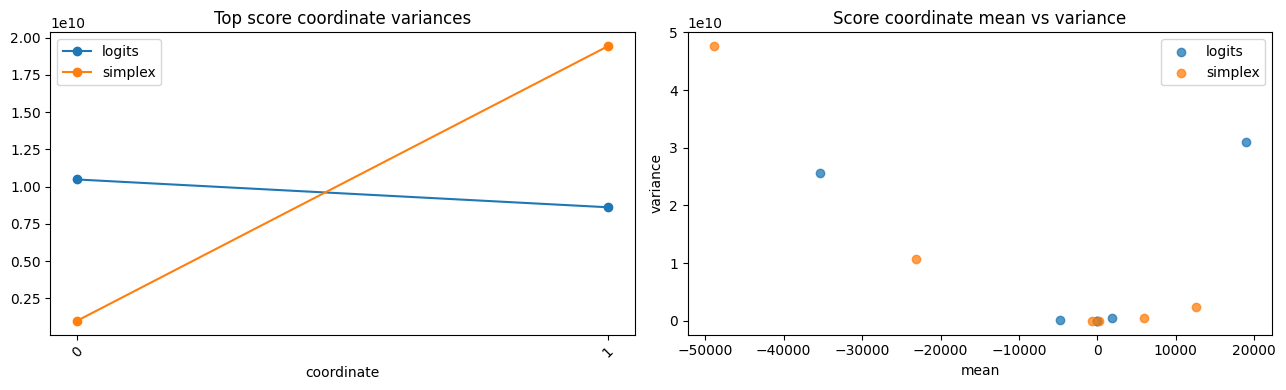

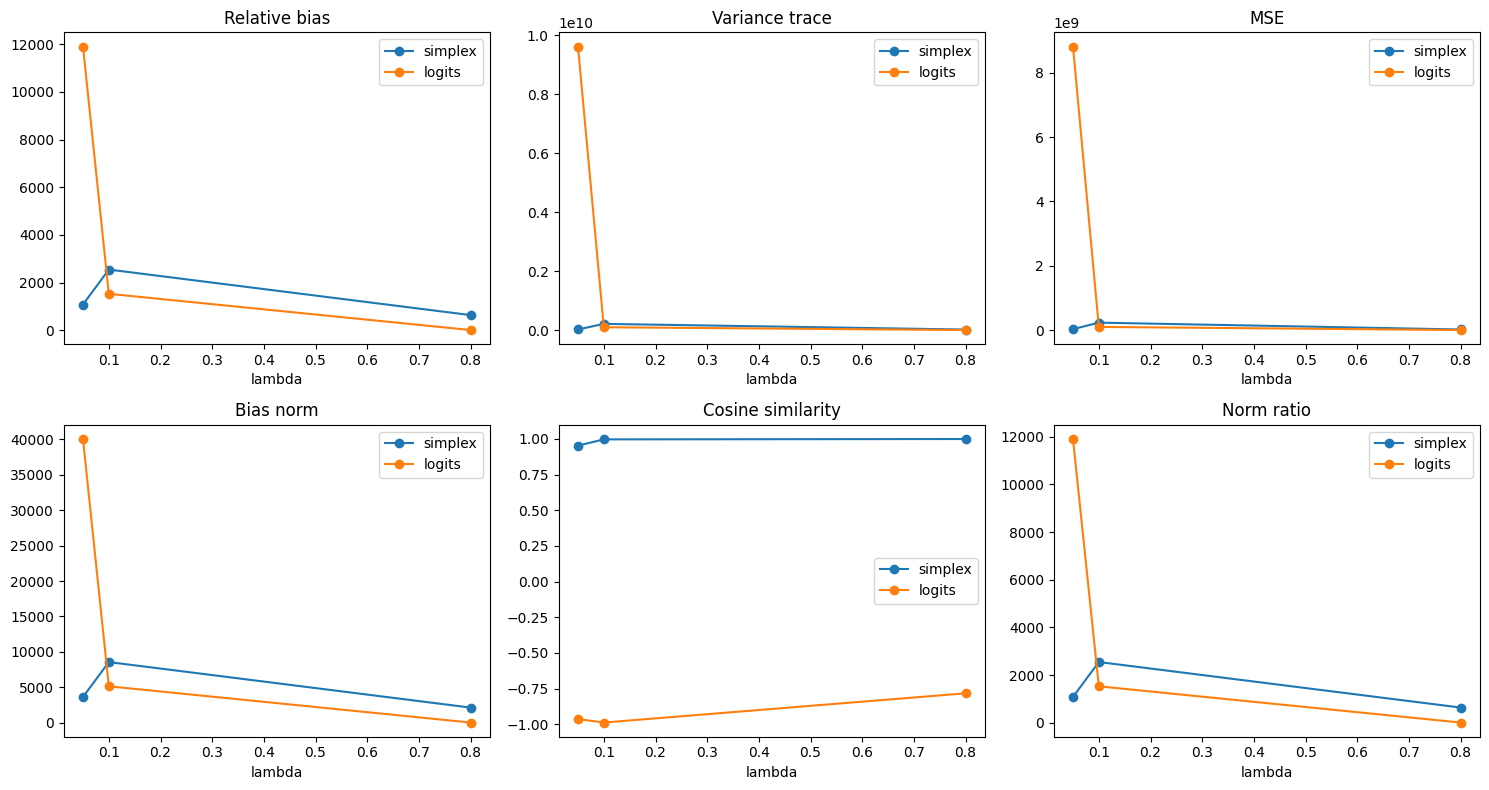

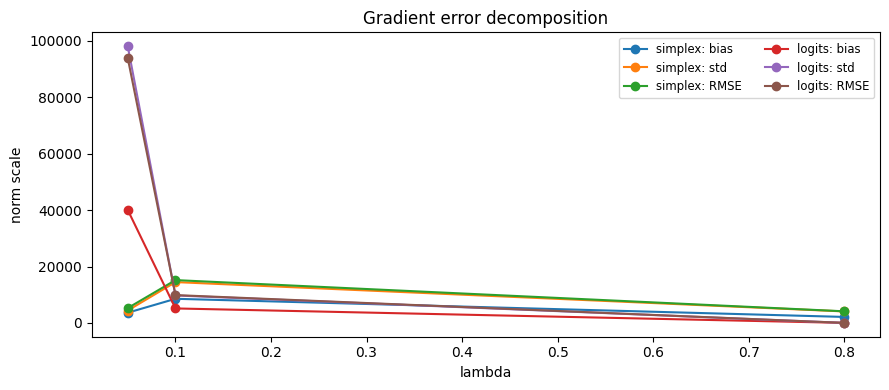

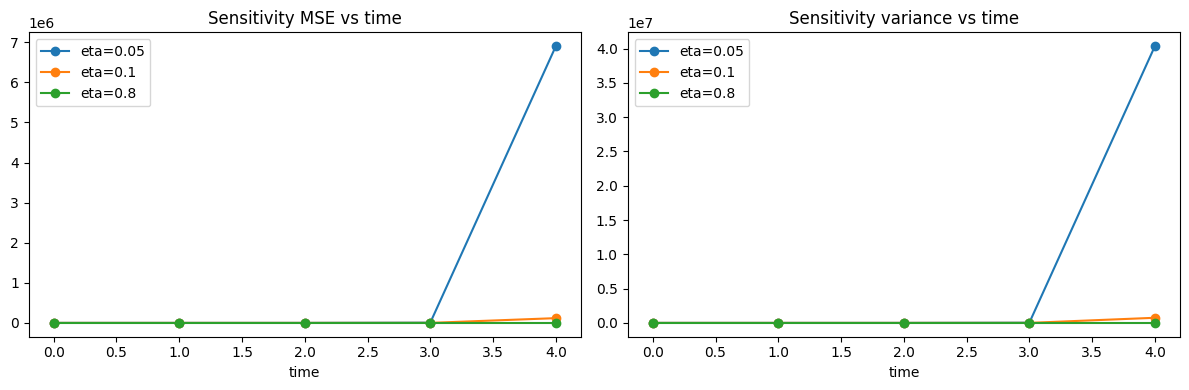

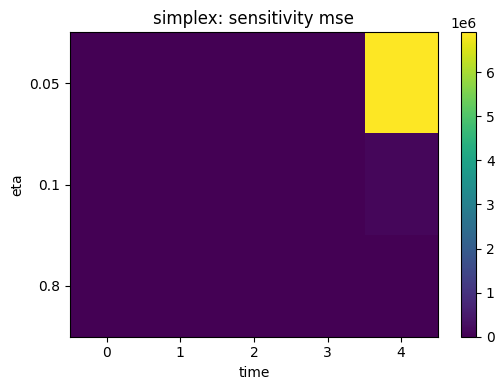

In [7]:
diagnostics = nh.load_diagnostic_data(bundle)
nh.plot_perturbation_geometry(diagnostics)
nh.plot_perturbation_slopes(diagnostics)
nh.plot_functional_law(diagnostics)
nh.plot_functional_signature_means(diagnostics)
nh.plot_score_validation(diagnostics)
nh.plot_score_coordinate_diagnostics(diagnostics)
nh.plot_gradient_validation(diagnostics)
nh.plot_gradient_error_decomposition(diagnostics)
nh.plot_sensitivity_validation(diagnostics)
nh.plot_sensitivity_heatmap(diagnostics)

## Total-Variation Calibration

Goal: compare the finite-state law perturbations in the same total-variation geometry used in the original two-state notebook.

For probability vectors $p,q$,

$$
d_{TV}(p,q)=\frac{1}{2}\|p-q\|_1.
$$

For the affine-simplex perturbation

$$
M^\lambda=(1-\lambda)\mu+\lambda Q,
$$

so pathwise

$$
d_{TV}(M^\lambda,\mu)=\lambda d_{TV}(Q,\mu)\leq \lambda.
$$

The table reports empirical $\mathbb{E}[d_{TV}]$, slack, and violations of this pathwise bound. For logits, the perturbation is applied in logit coordinates and has no analogous pathwise TV radius guarantee, so the table reports violations against the reference scale $\epsilon/2$.

In [8]:
tv_table = nh.perturbation_tv_comparison_table(diagnostics)
tv_table

,algorithm,parameter,value,samples,E_d_TV,median_d_TV,p90_d_TV,max_d_TV,comparison_kind,comparison_radius,pathwise_bound,violation_count,violation_rate,simplex_expected_unit_radius,simplex_min_slack,logit_reference_size,logit_mean_over_reference,logit_min_reference_slack
0,simplex,lambda,0.05,32,0.013559,0.009790,0.027394,0.034818,simplex pathwise bound lambda,0.050,0.05,0,0.00000,0.271172,0.015182,NaN,NaN,NaN
1,logits,epsilon,0.05,32,0.010006,0.009917,0.018066,0.021949,logit reference epsilon/2,0.025,NaN,0,0.00000,NaN,NaN,0.025,0.400248,0.003051
2,simplex,lambda,0.10,32,0.029798,0.025781,0.055143,0.074181,simplex pathwise bound lambda,0.100,0.10,0,0.00000,0.297984,0.025819,NaN,NaN,NaN
3,logits,epsilon,0.10,32,0.017484,0.013979,0.035173,0.051919,logit reference epsilon/2,0.050,NaN,1,0.03125,NaN,NaN,0.050,0.349683,-0.001919
4,simplex,lambda,0.80,32,0.285372,0.290574,0.448408,0.591008,simplex pathwise bound lambda,0.800,0.80,0,0.00000,0.356715,0.208992,NaN,NaN,NaN
5,logits,epsilon,0.80,32,0.161576,0.121858,0.398028,0.473096,logit reference epsilon/2,0.400,NaN,4,0.12500,NaN,NaN,0.400,0.403940,-0.073096


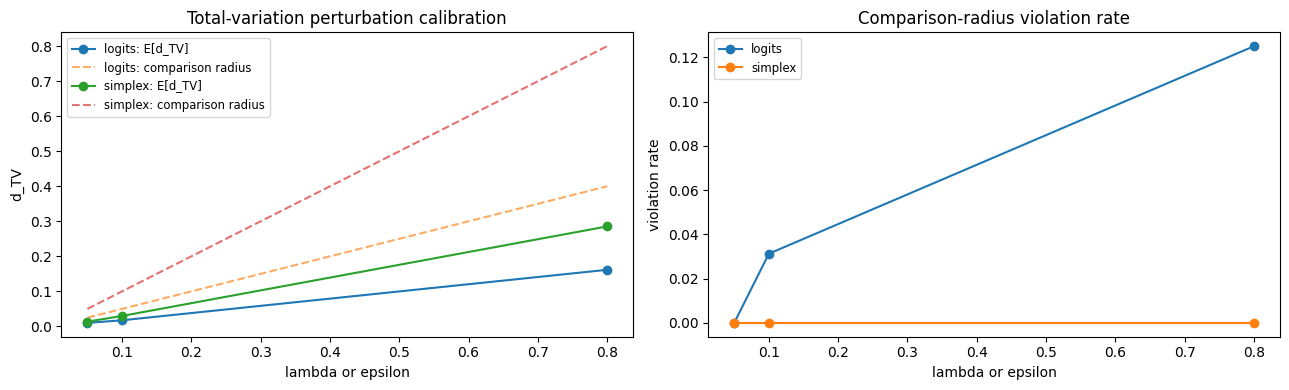

In [9]:
nh.plot_perturbation_tv_comparison(diagnostics)

## Scaling, Budget, And Optimization Summaries

Goal: measure how estimator quality and optimization performance change with simulator budget, auxiliary budget, horizon, and training time.

The budget heatmap varies main and auxiliary samples $(B,n)$ under the approximate cost model

$$
C\approx C_{main}B+C_{aux}n.
$$

The horizon plot studies how gradient error changes with $T$, and the optimization plots compare objective or cost gaps against iteration count, runtime, and simulator-call budget.

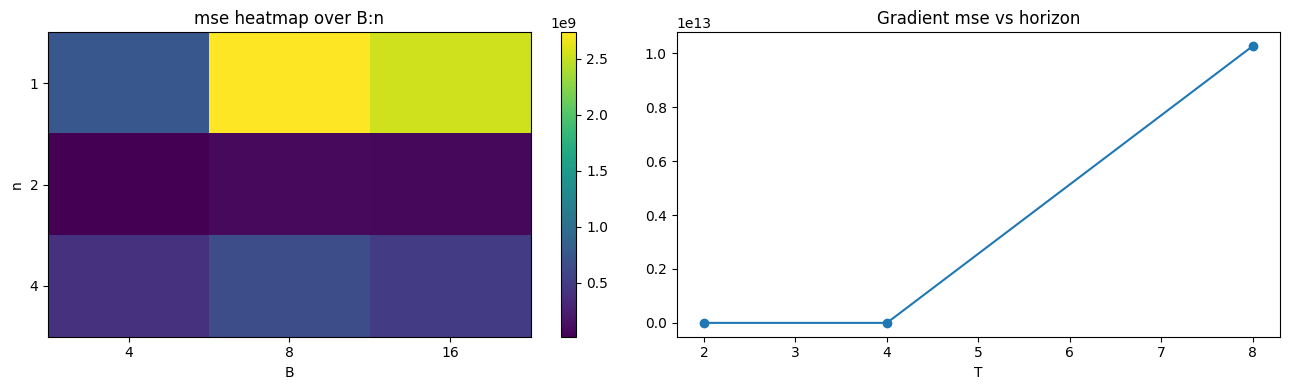

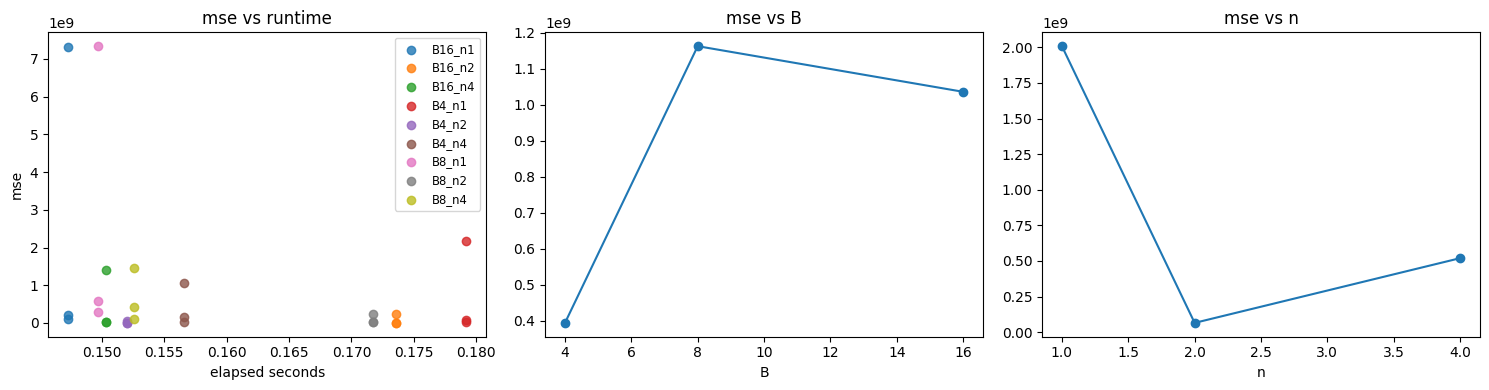

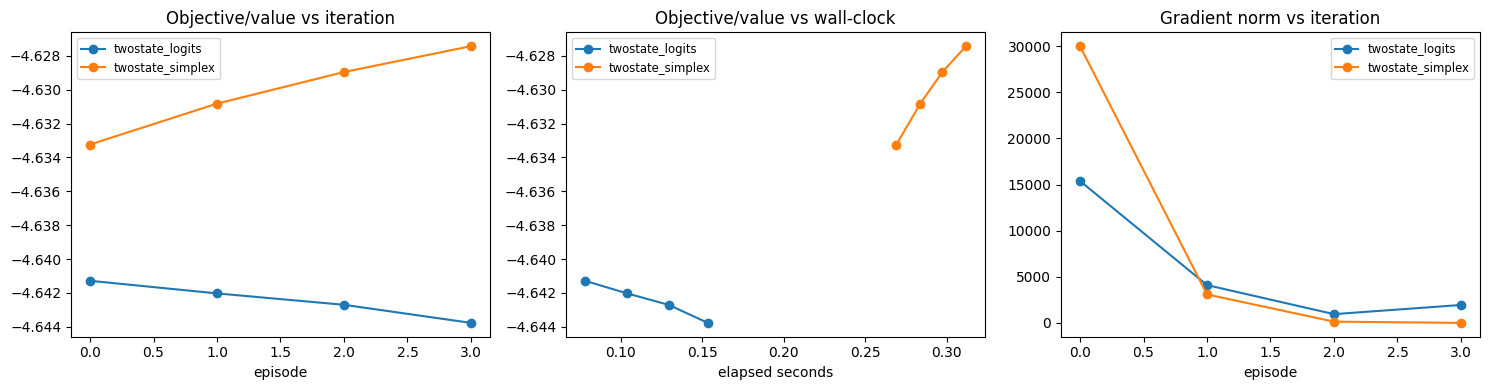

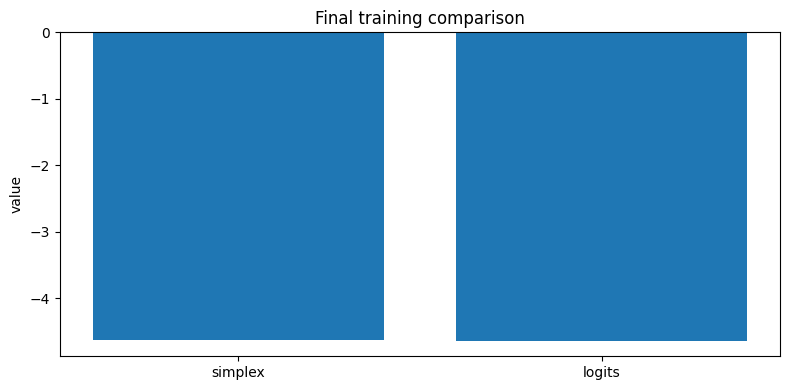

In [10]:
studies = nh.load_study_data(bundle)
grid_metrics = nh.load_study_grid_metrics(bundle)
optimization_history = nh.load_optimization_history(bundle)
nh.plot_budget_and_horizon(studies)
nh.plot_budget_pareto(studies, grid_metrics)
nh.plot_optimization_history(optimization_history)
nh.plot_optimization_summary(studies)

## Raw Tables For Custom Figures

Goal: expose the underlying CSV/JSON artifacts used by the plots so paper figures can be restyled or recomputed without rerunning training.

These tables are not new estimators. They are the saved values for population flows, policies, diagnostics, study grids, histories, and final metrics.

In [11]:
application["simplex"]["time_metrics"].head(), diagnostics["simplex"]["gradient"].head(), studies["budget"].head()

(        env  law_index  time  mass_state_1  target_state_1  target_abs_error
 0  twostate          0     0      0.800000             0.4          0.400000
 1  twostate          0     1      0.529539             0.4          0.129539
 2  twostate          0     2      0.434963             0.4          0.034963
 3  twostate          0     3      0.401891             0.4          0.001891
 4  twostate          0     4      0.390326             0.4          0.009674,
    lambda  replications  estimate_norm  variance_trace  \
 0    0.05             4    3627.359415    1.937136e+07   
 1    0.10             4    8562.427085    2.096816e+08   
 2    0.80             4    2132.311778    1.658833e+07   
 
    covariance_largest_eigenvalue  oracle_norm    bias_norm  relative_bias  \
 0                   1.650757e+07      3.36458  3624.152219    1077.148633   
 1                   2.080368e+08      3.36458  8559.071930    2543.875662   
 2                   1.658061e+07      3.36458  2128.947866